From https://eloy.readthedocs.io/en/latest/photometry/

In [1]:

from astropy.io import fits
from astropy.time import Time

from dateutil import parser
from glob import glob

images = glob("data/*.fits.fz")

# photometry on the stacked image
#file = "output/stack_image.fits"

file = images[0]

# get observation time from FITS header (SCI extension)
def observation_time(header):
    date_str = header["DATE-OBS"]
    return Time(parser.parse(date_str))


detected FWHM: 3.988022110548593


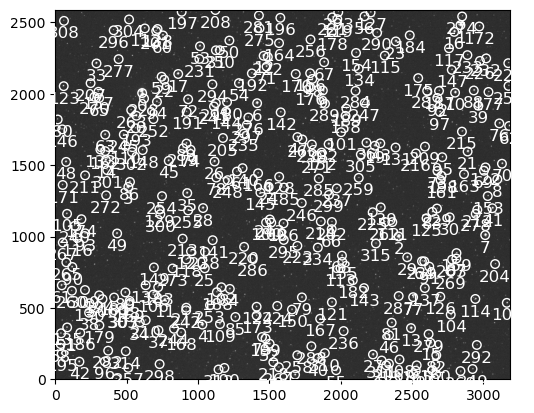

In [16]:

import matplotlib.pyplot as plt
import numpy as np
from astropy.coordinates import SkyCoord
import astropy.units as u

from eloy import psf, detection, utils
from eloy import viz

# calibration sequence

#trim = 10


def calibration_sequence(data, header):

    # trimming
    # todo - so calibration stars are not selected from the margin
    
    # detection
    regions = detection.stars_detection(data)

    # stars coords and cutouts
    region_coords = np.array([(r.centroid[1], r.centroid[0]) for r in regions])

    #note: cutouts are the small images of the stars, which are used to model the PSF
    cutouts = utils.cutout(data, region_coords, (50, 50))

    # epsf modeling
    cutouts_normalized = cutouts / np.nanmax(cutouts, (1, 2))[:, None, None]
    # note epsf is the empirical PSF, which is the median of the normalized cutouts
    epsf = np.nanmedian(cutouts_normalized, 0)
    psf_params = psf.fit_gaussian(epsf)
    fwhm = psf.gaussian_sigma_to_fwhm * np.mean(
        [psf_params["sigma_x"], psf_params["sigma_y"]]
    )
    
    print("detected FWHM:", fwhm)

    del (
        cutouts_normalized,
        regions,
        cutouts,
        epsf,
    )

    return region_coords, fwhm


# and create a calibration sequence from the reference image

data = fits.getdata(file)
header = fits.getheader(file, extname="sci")

centroid_coords, fwhm = calibration_sequence(data, header)

plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
viz.plot_marks(*centroid_coords.T, color="w", label=True, ms=30)


In [14]:
data

array([[205.08223, 210.68604, 197.74779, ..., 209.2726 , 205.65805,
        202.57486],
       [203.5914 , 204.31313, 199.76512, ..., 203.41893, 204.41704,
        217.10034],
       [205.8918 , 203.40259, 199.87032, ..., 204.35869, 203.45387,
        208.97046],
       ...,
       [204.40573, 203.39185, 207.24681, ..., 206.2928 , 206.24573,
        211.3844 ],
       [205.22847, 207.63922, 205.23723, ..., 207.0039 , 207.43741,
        208.83836],
       [209.5377 , 205.68796, 207.29446, ..., 209.94559, 207.70589,
        208.03465]], shape=(2590, 3184), dtype=float32)

In [20]:

from tqdm.auto import tqdm
from skimage.transform import AffineTransform
from collections import defaultdict
from eloy import centroid, photometry

n_stars = 300

# relative apertures radii to use for the aperture photometry, to be scaled by the FWHM of the PSF
# TODO: rewrite this with a simpler single aperature scale
# TODO: rewrite for vanilla photutils

relative_apertures_radii = np.linspace(0.1, 5, 40)


### aperture photometry

# a list of radii to use for the aperture photometry, scaled by the FWHM of the PSF
apertures_radii = relative_apertures_radii * fwhm

# for each star, calculate the flux in each aperture
flux_ap = photometry.aperture_photometry(
    data, centroid_coords, apertures_radii
)

### annulus background correction

# create an array of the inner and outer radii of the annulus to use for the background estimation,
# scaled by the FWHM of the PSF
annulus_radii = (np.max(apertures_radii), 8 * fwhm)
aperture_area = np.pi * apertures_radii**2

# find the background for each star using the annulus method
bkg = photometry.annulus_sigma_clip_median(
    data, centroid_coords, *annulus_radii
)

# multiply the background by the area of each aperture 
# to get the total background flux for each star, for each aperture size
bkg = bkg[:, None] * aperture_area[None, :]


jd = observation_time(header).jd

# measurements data
#data["bkg"]=bkg
#data["fluxes"]=flux
#data["fwhm"]=fwhm
#data["time"]=jd


In [198]:
header

SIMPLE  =                    T / file does conform to FITS standard             
BITPIX  =                  -32 / data type of original image                    
NAXIS   =                    2 / dimension of original image                    
NAXIS1  =                 3184 / length of original image axis                  
NAXIS2  =                 2590 / length of original image axis                  
EXTNAME = 'SCI     '                                                            
ORIGIN  = 'NxtAstro'           / Organization responsible for the data          
SITEID  = 'sro     '           / ID code of the Observatory site                
SITE    = 'Next Astro Site'    / Site of the Observatory                        
TELID   = 'baron   '           / ID code of the Telescope                       
TELESCOP= 'baron   '           / ID code of the Telescope                       
LATITUDE=              37.0713 / [deg North] Telescope Latitude                 
LONGITUD=            -119.41

/tmp/ipykernel_118484/2413608124.py:7: RuntimeWarning: invalid value encountered in log10
  inst_mags = -2.5*np.log10(flux/exptime)*u.mag


Text(0, 0.5, 'instrumental magnitudes')

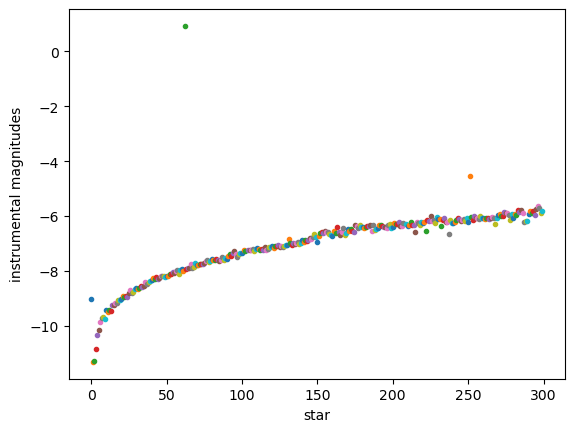

In [208]:
import matplotlib.pyplot as plt

# we remove the background from the annulus aperture
flux = flux_ap-bkg

exptime = header["EXPTIME"] 
inst_mags = -2.5*np.log10(flux/exptime)*u.mag

#plot some random photometry data
for i in range(0,n_stars):
    plt.plot( i, inst_mags[ i,19], ".")

plt.xlabel("star")
plt.ylabel("instrumental magnitudes")


Target index is 2
[2405.74074074 1000.27441077]
<SkyCoord (ICRS): (ra, dec) in deg
    (297.71101239, 48.08258218)>
<SkyCoord (ICRS): (ra, dec) in deg
    (297.70936374, 48.0808615)>


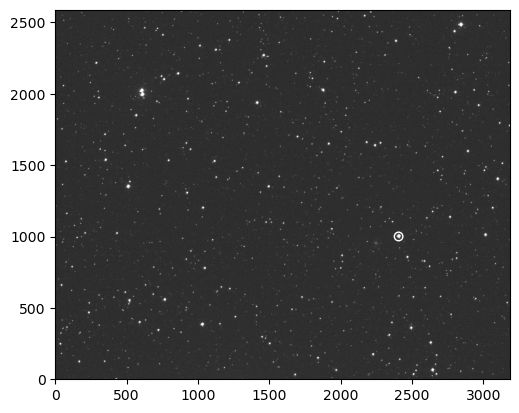

In [23]:

# need to identify the target!
from astroquery.mast import Mast
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS


#transform centroid_coords to skycoords
wcs = WCS(header)
centroid_radec = wcs.pixel_to_world(*centroid_coords.T)

mast = Mast()
target_radec = mast.resolve_object("HAT-P-11")
target_index = int(target_radec.match_to_catalog_sky(centroid_radec)[0])

print(f"Target index is {target_index}")
print(f"{centroid_coords[target_index]}")
print(f"{centroid_radec[target_index]}")
print(f"{target_radec}")

plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
viz.plot_marks(centroid_coords[target_index][0],centroid_coords[target_index][1], color="w", ms=30)

target = centroid_coords[target_index]

In [114]:
# cross match target stars from GAIA DR3 Synthetic Photometry Catalogue

from astroquery.gaia import Gaia
from astropy.wcs.utils import pixel_to_skycoord
import requests

# !!! TODO: this is not the correct bounds calculation
# should use a polygon or a box around the image, not just the center and the width/height

(img_width, img_height) = wcs.pixel_shape
img_center_coord = wcs.pixel_to_world(img_width/2, img_height/2)
img_top_left = wcs.pixel_to_world(0, 0)
img_coord_width = img_top_left.separation(wcs.pixel_to_world(img_width, 0))
img_coord_height = img_top_left.separation(wcs.pixel_to_world(0, img_height))

where_min_magnitude = "src.phot_g_mean_mag < 16"

where_box_search = f"""1 = CONTAINS(
            POINT(src.ra, src.dec), 
            BOX({img_center_coord.ra.deg}, {img_center_coord.dec.deg}, {img_coord_width.deg}, {img_coord_height.deg})
        )"""

query = f"""
SELECT src.ra, src.dec, gspc.*
    FROM gaiadr3.synthetic_photometry_gspc AS gspc
    JOIN gaiadr3.gaia_source AS src 
        ON gspc.source_id = src.source_id
    
    WHERE {where_min_magnitude} 
        AND {where_box_search}
    ;
"""


In [108]:
job = Gaia.launch_job(query)

results = job.get_results()


ra,dec,source_id,c_star,u_jkc_flux,u_jkc_flux_error,u_jkc_mag,u_jkc_flag,b_jkc_flux,b_jkc_flux_error,b_jkc_mag,b_jkc_flag,v_jkc_flux,v_jkc_flux_error,v_jkc_mag,v_jkc_flag,r_jkc_flux,r_jkc_flux_error,r_jkc_mag,r_jkc_flag,i_jkc_flux,i_jkc_flux_error,i_jkc_mag,i_jkc_flag,u_sdss_flux,u_sdss_flux_error,u_sdss_mag,u_sdss_flag,g_sdss_flux,g_sdss_flux_error,g_sdss_mag,g_sdss_flag,r_sdss_flux,r_sdss_flux_error,r_sdss_mag,r_sdss_flag,i_sdss_flux,i_sdss_flux_error,i_sdss_mag,i_sdss_flag,z_sdss_flux,z_sdss_flux_error,z_sdss_mag,z_sdss_flag,y_ps1_flux,y_ps1_flux_error,y_ps1_mag,y_ps1_flag,f606w_acswfc_flux,f606w_acswfc_flux_error,f606w_acswfc_mag,f606w_acswfc_flag,f814w_acswfc_flux,f814w_acswfc_flux_error,f814w_acswfc_mag,f814w_acswfc_flag
deg,deg,,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,
float64,float64,int64,float32,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16
297.60668096155604,47.860555007036965,2086414817994429184,-0.00039434433,1.6459068e-16,1.4442619e-18,13.610087,1,2.1961694e-16,5.3428325e-19,13.674835,1,1.9607852e-16,3.5152066e-19,13.182825,1,1.5816497e-16,2.2605502e-19,12.875424,1,1.1143346e-16,1.3182171e-19,12.561261,1,8.264772e-29,6.966353e-31,14.419423,0,1.6211291e-28,3.4100257e-31,13.354756,0,2.1820488e-28,3.208418e-31,13.044939,0,2.3514772e-28,2.8332867e-31,12.952348,0,2.3783918e-28,3.4584744e-31,12.935692,0,2.3810038e-28,6.3836533e-31,12.9648,0,1.7740029e-16,1.8201777e-19,13.039515,1,1.09507324e-16,1.2338198e-19,12.566192,1
297.46485399267965,47.91719173346202,2086427771615750656,-0.005532503,--,--,--,0,9.821735e-18,5.960228e-20,17.048529,1,1.2164858e-17,4.0243245e-20,16.201132,1,1.1382833e-17,2.8683803e-20,15.732574,1,8.880962e-18,2.1258081e-20,15.30765,1,--,--,--,0,8.3733115e-30,3.535105e-32,16.572058,1,1.5274502e-29,4.513337e-32,15.932182,1,1.8281795e-29,4.7176226e-32,15.725653,1,1.9804345e-29,6.9001236e-32,15.634499,1,2.0467517e-29,1.7358513e-31,15.629037,1,1.1862483e-17,2.561051e-20,15.976461,1,8.745456e-18,2.0228972e-20,15.310344,1
297.45780467283043,47.920874479440755,2086427840335225856,-0.005194664,8.397942e-18,2.322602e-19,16.840668,1,1.3767105e-17,6.631437e-20,16.681894,1,1.4717396e-17,4.464705e-20,15.994323,1,1.2755885e-17,3.2393436e-20,15.608924,1,9.513764e-18,2.2386026e-20,15.232919,1,4.260308e-30,1.211141e-31,17.638897,1,1.1041392e-29,4.0091425e-32,16.27174,1,1.7308578e-29,5.0785006e-32,15.796447,1,1.9848852e-29,5.056566e-32,15.636361,1,2.0903335e-29,7.2056546e-32,15.575861,1,2.1353112e-29,1.8227695e-31,15.583047,1,1.3790065e-17,2.8324328e-20,15.812984,1,9.3784555e-18,2.1521765e-20,15.234471,1
297.4540758991062,47.92962053895756,2086427874694966144,0.0127648115,1.0260789e-17,2.6981711e-19,16.623148,1,1.4132943e-17,6.982548e-20,16.653418,1,1.4945274e-17,4.59808e-20,15.97764,1,1.3066359e-17,3.2663886e-20,15.582813,1,9.907423e-18,2.3530642e-20,15.188898,1,5.1874784e-30,1.3908168e-31,17.42511,1,1.12543575e-29,4.107667e-32,16.250998,1,1.7656136e-29,5.170314e-32,15.77486,1,2.0564276e-29,5.354536e-32,15.597917,1,2.1920196e-29,7.474185e-32,15.524289,1,2.2615183e-29,1.8799555e-31,15.5206995,1,1.4059665e-17,2.9424582e-20,15.791963,1,9.753671e-18,2.2543444e-20,15.191879,1
297.47562584990635,47.96151729225025,2086428012133943296,0.00039052963,3.9091954e-17,5.104381e-19,15.170881,1,6.069865e-17,1.5563649e-19,15.071053,1,6.357205e-17,1.2115329e-19,14.405

In [210]:
from astropy.coordinates import match_coordinates_sky
from astropy.wcs.utils import pixel_to_skycoord
from astropy.table import hstack

centroid_skycoords = pixel_to_skycoord(*centroid_coords.T, wcs)

gaia_table=results

#extract coordinates of catalog stars
gaia_skycoords = SkyCoord(gaia_table["ra"], gaia_table["dec"], frame="icrs")
gaia_match = match_coordinates_sky(centroid_skycoords, gaia_skycoords)
indices = gaia_match[0]

centroid_table = QTable([centroid_coords.T[0], centroid_coords.T[1],centroid_skycoords.ra, centroid_skycoords.dec, gaia_match[1], flux.T[20], inst_mags.T[20]], 
                        names=["centroid_x", "centroid_y", "centroid_ra","centroid_dec", "gaia_match_err", "inst_flux", "inst_mag"])


catalog_table = hstack([centroid_table, gaia_table[indices]])#, panstarrs_table])
catalog_table_masked = catalog_table[(catalog_table["gaia_match_err"]<2*u.arcsec) ]
catalog_skycoords = SkyCoord(ra=catalog_table_masked["ra"],dec=catalog_table_masked["dec"], frame="icrs")
catalog_pixels = wcs.world_to_pixel(catalog_skycoords.unmasked)


#plt.imshow(viz.z_scale(data), cmap="Greys_r", origin="lower")
#viz.plot_marks(catalog_pixels[0], catalog_pixels[1], label=catalog_table_masked["g_sdss_mag"],color="w", ms=30)


In [221]:
gaia_table


ra,dec,source_id,c_star,u_jkc_flux,u_jkc_flux_error,u_jkc_mag,u_jkc_flag,b_jkc_flux,b_jkc_flux_error,b_jkc_mag,b_jkc_flag,v_jkc_flux,v_jkc_flux_error,v_jkc_mag,v_jkc_flag,r_jkc_flux,r_jkc_flux_error,r_jkc_mag,r_jkc_flag,i_jkc_flux,i_jkc_flux_error,i_jkc_mag,i_jkc_flag,u_sdss_flux,u_sdss_flux_error,u_sdss_mag,u_sdss_flag,g_sdss_flux,g_sdss_flux_error,g_sdss_mag,g_sdss_flag,r_sdss_flux,r_sdss_flux_error,r_sdss_mag,r_sdss_flag,i_sdss_flux,i_sdss_flux_error,i_sdss_mag,i_sdss_flag,z_sdss_flux,z_sdss_flux_error,z_sdss_mag,z_sdss_flag,y_ps1_flux,y_ps1_flux_error,y_ps1_mag,y_ps1_flag,f606w_acswfc_flux,f606w_acswfc_flux_error,f606w_acswfc_mag,f606w_acswfc_flag,f814w_acswfc_flux,f814w_acswfc_flux_error,f814w_acswfc_mag,f814w_acswfc_flag
deg,deg,,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,,W / (nm m2),W / (nm m2),mag,
float64,float64,int64,float32,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16,float32,float32,float32,int16
297.60668096155604,47.860555007036965,2086414817994429184,-0.00039434433,1.6459068e-16,1.4442619e-18,13.610087,1,2.1961694e-16,5.3428325e-19,13.674835,1,1.9607852e-16,3.5152066e-19,13.182825,1,1.5816497e-16,2.2605502e-19,12.875424,1,1.1143346e-16,1.3182171e-19,12.561261,1,8.264772e-29,6.966353e-31,14.419423,0,1.6211291e-28,3.4100257e-31,13.354756,0,2.1820488e-28,3.208418e-31,13.044939,0,2.3514772e-28,2.8332867e-31,12.952348,0,2.3783918e-28,3.4584744e-31,12.935692,0,2.3810038e-28,6.3836533e-31,12.9648,0,1.7740029e-16,1.8201777e-19,13.039515,1,1.09507324e-16,1.2338198e-19,12.566192,1
297.46485399267965,47.91719173346202,2086427771615750656,-0.005532503,--,--,--,0,9.821735e-18,5.960228e-20,17.048529,1,1.2164858e-17,4.0243245e-20,16.201132,1,1.1382833e-17,2.8683803e-20,15.732574,1,8.880962e-18,2.1258081e-20,15.30765,1,--,--,--,0,8.3733115e-30,3.535105e-32,16.572058,1,1.5274502e-29,4.513337e-32,15.932182,1,1.8281795e-29,4.7176226e-32,15.725653,1,1.9804345e-29,6.9001236e-32,15.634499,1,2.0467517e-29,1.7358513e-31,15.629037,1,1.1862483e-17,2.561051e-20,15.976461,1,8.745456e-18,2.0228972e-20,15.310344,1
297.45780467283043,47.920874479440755,2086427840335225856,-0.005194664,8.397942e-18,2.322602e-19,16.840668,1,1.3767105e-17,6.631437e-20,16.681894,1,1.4717396e-17,4.464705e-20,15.994323,1,1.2755885e-17,3.2393436e-20,15.608924,1,9.513764e-18,2.2386026e-20,15.232919,1,4.260308e-30,1.211141e-31,17.638897,1,1.1041392e-29,4.0091425e-32,16.27174,1,1.7308578e-29,5.0785006e-32,15.796447,1,1.9848852e-29,5.056566e-32,15.636361,1,2.0903335e-29,7.2056546e-32,15.575861,1,2.1353112e-29,1.8227695e-31,15.583047,1,1.3790065e-17,2.8324328e-20,15.812984,1,9.3784555e-18,2.1521765e-20,15.234471,1
297.4540758991062,47.92962053895756,2086427874694966144,0.0127648115,1.0260789e-17,2.6981711e-19,16.623148,1,1.4132943e-17,6.982548e-20,16.653418,1,1.4945274e-17,4.59808e-20,15.97764,1,1.3066359e-17,3.2663886e-20,15.582813,1,9.907423e-18,2.3530642e-20,15.188898,1,5.1874784e-30,1.3908168e-31,17.42511,1,1.12543575e-29,4.107667e-32,16.250998,1,1.7656136e-29,5.170314e-32,15.77486,1,2.0564276e-29,5.354536e-32,15.597917,1,2.1920196e-29,7.474185e-32,15.524289,1,2.2615183e-29,1.8799555e-31,15.5206995,1,1.4059665e-17,2.9424582e-20,15.791963,1,9.753671e-18,2.2543444e-20,15.191879,1
297.47562584990635,47.96151729225025,2086428012133943296,0.00039052963,3.9091954e-17,5.104381e-19,15.170881,1,6.069865e-17,1.5563649e-19,15.071053,1,6.357205e-17,1.2115329e-19,14.405

In [252]:

# now compute the offset between instrumental and catalog magnitudes for the matched stars
gspc_filter_name = "g_sdss"

mag_threshold = 16*u.mag
comp_table = catalog_table_masked[(catalog_table_masked[gspc_filter_name+"_mag"]<mag_threshold) ]#& (catalog_table_masked[gspc_filter_name+"_flag"] == 1)]

# should probably filter comps on color and magnitude as well
target_vb = 1.2*u.mag
target_mag = 10.6*u.mag
comp_colors = comp_table["b_jkc_mag"] - comp_table["v_jkc_mag"]
color_threshold = 0.1*u.mag

comp_table = comp_table[(comp_colors < target_vb + color_threshold) & (comp_colors > target_vb - color_threshold)]
#comp_table = comp_table[(comp_table[gspc_filter_name+"_mag"] < target_mag+2*u.mag) & (comp_table[gspc_filter_name+"_mag"] > target_mag-2*u.mag)]

display((comp_table["inst_mag"]))
display(comp_table[gspc_filter_name+"_mag"])
offset = (comp_table["inst_mag"]) - comp_table[gspc_filter_name+"_mag"]
print(offset)

<Quantity [-9.17872391, -9.06875909, -8.12442442, -8.05238532, -7.71343161,
           -7.59701986, -7.5473522 , -7.61299302, -7.48779927, -7.37106127,
           -7.3918444 , -7.35613991, -7.18044246, -7.09324104, -6.67526606,
           -6.77242941, -6.60803795, -6.36597803, -6.40935983, -6.01530167,
           -6.10504794, -6.24330632, -6.23203106, -6.16615682, -6.23642552,
           -6.00111922, -5.96140938, -6.16912129, -5.72555188] mag>

<MaskedQuantity [12.089061 , 12.1964445, 13.11746  , 13.23735  ,
                 13.557024 , 13.706432 , 13.69891  , 13.686068 ,
                 13.758525 , 13.878638 , 13.873497 , 13.869718 ,
                 14.081005 , 14.170926 , 14.57098  , 14.485286 ,
                 14.705085 , 14.89096  , 14.833512 , 15.176841 ,
                 15.197745 , 15.1094265, 15.010971 , 15.130289 ,
                 15.160708 , 15.273704 , 15.299047 , 15.464378 ,
                 15.507928 ] mag>

[-21.26778469 -21.2652036  -21.24188467 -21.28973578 -21.27045561
 -21.30345221 -21.24626196 -21.29906061 -21.24632416 -21.24969953
 -21.26534141 -21.22585751 -21.26144756 -21.26416714 -21.24624613
 -21.25771517 -21.31312275 -21.25693777 -21.24287213 -21.19214245
 -21.30279326 -21.35273282 -21.24300213 -21.2964459  -21.39713395
 -21.27482279 -21.26045685 -21.63349965 -21.23347978] mag


In [253]:
#some stats on the offsets
print("offset mean", np.mean(offset))
print("offset median", np.median(offset))
print("offset std", np.std(offset))
print("offset var", np.var(offset))
#print("offset percentile", np.percentile(offset, q))
print("offset min, max", np.min(offset), np.max(offset))
display(offset)


offset mean -21.282761378188994 mag
offset median -21.264167135806808 mag
offset std 0.07672095974155305 mag
offset var 0.005886105663665004 mag2
offset min, max -21.63349964617037 mag -21.192142451533975 mag


<MaskedQuantity [-21.26778469, -21.2652036 , -21.24188467, -21.28973578,
                 -21.27045561, -21.30345221, -21.24626196, -21.29906061,
                 -21.24632416, -21.24969953, -21.26534141, -21.22585751,
                 -21.26144756, -21.26416714, -21.24624613, -21.25771517,
                 -21.31312275, -21.25693777, -21.24287213, -21.19214245,
                 -21.30279326, -21.35273282, -21.24300213, -21.2964459 ,
                 -21.39713395, -21.27482279, -21.26045685, -21.63349965,
                 -21.23347978] mag>

In [254]:
q25, q75 = np.percentile(offset, [25, 75])
iqr = q75 - q25

# Define bounds
lower_bound = q25 - (1.5 * iqr)
upper_bound = q75 + (1.5 * iqr)

# Filter the array
clean_data = offset[(offset >= lower_bound) & (offset <= upper_bound)]

print("clean offset mean", np.mean(clean_data))
print("clean offset median", np.median(clean_data))
print("clean offset std", np.std(clean_data))
print("clean offset var", np.var(clean_data))
print("clean offset min, max", np.min(clean_data), np.max(clean_data))
display(clean_data)


clean offset mean -21.265535050727948 mag
clean offset median -21.261447558968793 mag
clean offset std 0.031379690528993164 mag
clean offset var 0.0009846849776953832 mag2
clean offset min, max -21.352732816201616 mag -21.192142451533975 mag


<MaskedQuantity [-21.26778469, -21.2652036 , -21.24188467, -21.28973578,
                 -21.27045561, -21.30345221, -21.24626196, -21.29906061,
                 -21.24632416, -21.24969953, -21.26534141, -21.22585751,
                 -21.26144756, -21.26416714, -21.24624613, -21.25771517,
                 -21.31312275, -21.25693777, -21.24287213, -21.19214245,
                 -21.30279326, -21.35273282, -21.24300213, -21.2964459 ,
                 -21.27482279, -21.26045685, -21.23347978] mag>